In [1]:
import skimage as ski
import napari
import numpy as np
import pandas as pd
import glob
import morphops as mops
import plotly.express as px
from sklearn.decomposition import PCA
import umap
import plotly.graph_objs as go


In [2]:
viewer = napari.Viewer()

Example ORS Session:  S:\micro\pat\rf2602\CitrateIP\For_Quantification\819218-6_WT_DBAB6_Citrate_IP_E18.5\819218-6_WT_DBAB6_Citrate_IP_E18.5_Rec

# Load data

In [102]:
csv_files = glob.glob('*.csv')

In [103]:
df = pd.DataFrame()
for idx, f in enumerate(csv_files):
    cdf = pd.read_csv(f)
    cdf['file'] = f
    df = pd.concat([df, cdf])


In [104]:
df

,SERIES,COLOR,FRAME,X,Y,Z,file
0,1,Red,0,7.729314,4.173595,14.561192,818236-3_Splotch;Tcof1_doublemut.csv
1,2,Red,0,7.627205,4.366757,15.132219,818236-3_Splotch;Tcof1_doublemut.csv
2,3,Red,0,7.135882,4.998781,15.366384,818236-3_Splotch;Tcof1_doublemut.csv
3,4,Red,0,6.886706,5.284758,16.141541,818236-3_Splotch;Tcof1_doublemut.csv
4,5,Red,0,6.266539,5.763670,16.836201,818236-3_Splotch;Tcof1_doublemut.csv
...,...,...,...,...,...,...,...
21,22,Cyan,0,8.539819,5.376150,18.566084,820352-6_WT.csv
22,23,Cyan,0,8.773610,5.130564,18.511444,820352-6_WT.csv
23,24,Cyan,0,8.372392,4.464474,18.516514,820352-6_WT.csv
24,25,Cyan,0,8.462430,5.054045,18.626419,820352-6_WT.csv


px.scatter_3d(df, x='PosX', y='PosY', z='PosZ', animation_frame='file', height=800)

In [105]:
mandible = True

if mandible:
    results_dir = 'results/'
else:
    results_dir = 'maxilla_results/'


In [106]:
mandible_pts = [1,2,3,4,5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
#mandible_pts = [1,2,3,4,5, 6, 7, 8, 9, 10, 11, 12, 16]
#mandible_pts = [1,2,3,4,5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16]
#mandible_pts = [1,2, 8, 9, 14, 16]

maxilla_pts = [17,18,19,20,21, 22, 23, 24, 25, 26]

# Procrustes

In [107]:
# Mandible only
if mandible:
    df = df[df['SERIES'].astype(str).isin([str(i) for i in mandible_pts])]
else:
    df = df[df['SERIES'].astype(str).isin([str(i) for i in maxilla_pts])]
df['NumPoints'] = df.groupby(['file'])['SERIES'].transform('size')

mode = df['NumPoints'].mode().values[0]
df = df[df['NumPoints']==mode]
df['pos_idx'] = df['SERIES']


C:\Users\smc\AppData\Local\Temp\ipykernel_28180\400248667.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [108]:
unique_files = df['file'].drop_duplicates()
unique_files = unique_files.values

In [109]:
len(unique_files)

20

In [110]:
num_pts = int(df.shape[0]/len(unique_files))
data = np.reshape(df[['X', 'Y', 'Z']].to_numpy(), (-1, num_pts, 3))

In [111]:
res = mops.gpa(data)

ssq diff 0.0


In [112]:
aligned_x = -res['aligned'][:,:,0]
aligned_y = -res['aligned'][:,:,1]
aligned_z = -res['aligned'][:,:,2]

In [113]:
pts_per_img = res['aligned'].shape[1]

In [114]:
plot_df = pd.DataFrame({'x_aligned':aligned_y.flatten(), 'y_aligned':aligned_x.flatten(), 'z_aligned':aligned_z.flatten(), 'name':np.repeat(unique_files, pts_per_img)}).reset_index().reset_index()
plot_df['pos_idx'] = plot_df['level_0'] % pts_per_img + 1 
plot_df['pos_idx'] = plot_df['pos_idx'].astype(str)

In [115]:
plot_df

,level_0,index,x_aligned,y_aligned,z_aligned,name,pos_idx
0,0,0,0.410335,-0.007442,0.218707,818236-3_Splotch;Tcof1_doublemut.csv,1
1,1,1,0.357050,-0.013661,0.147058,818236-3_Splotch;Tcof1_doublemut.csv,2
2,2,2,0.235233,-0.005406,0.145413,818236-3_Splotch;Tcof1_doublemut.csv,3
3,3,3,0.151450,-0.002210,0.050905,818236-3_Splotch;Tcof1_doublemut.csv,4
4,4,4,0.019191,0.031441,-0.018924,818236-3_Splotch;Tcof1_doublemut.csv,5
...,...,...,...,...,...,...,...
315,315,315,-0.232629,-0.041958,-0.023244,820352-6_WT.csv,12
316,316,316,-0.063824,-0.025857,0.067417,820352-6_WT.csv,13
317,317,317,0.044089,0.054617,0.069154,820352-6_WT.csv,14
318,318,318,0.200288,-0.031018,0.246079,820352-6_WT.csv,15


In [116]:
plot_df['Background'] = 'WT'
plot_df.loc[plot_df['name'].str.contains('Tcof1'), 'Background'] = 'Tcof1'
plot_df.loc[plot_df['name'].str.contains('Splotch'), 'Background'] = 'Splotch'
plot_df.loc[plot_df['name'].str.contains('Splotch;Tcof1'), 'Background'] = 'Splotch;Tcof1'

plot_df['Mutation'] = 'None'
plot_df.loc[plot_df['name'].str.contains('singlemut'), 'Mutation'] = 'Single'
plot_df.loc[plot_df['name'].str.contains('doublemut'), 'Mutation'] = 'Double'

plot_df['BackgroundMutation'] = plot_df['Background'] + '_' + plot_df['Mutation']

NOTE:  Looking at the plot above, it appears pos_idx=13 is very different for Moderate vs Mild, but since everything else is pretty similar I think it dampens the "distance" between WT and Moderate.  Maybe we should focus on the jaw only for the procrustes?

In [117]:
category_orders={'Background':['WT', 'Splotch', 'Tcof1', 'Splotch;Tcof1',]}

In [118]:
px.scatter_3d(plot_df, x='x_aligned', y='y_aligned', z='z_aligned', color='Background', hover_data=['pos_idx', 'name'], title='Aligned Mandible Points', width=800, height=800, category_orders=category_orders,)

In [119]:
agged = plot_df.groupby(['Background', 'pos_idx']).agg({'x_aligned':'mean', 'y_aligned':'mean', 'z_aligned':'mean'}).reset_index()


In [120]:
pagged = agged.pivot(index='pos_idx', columns='Background', values=['x_aligned', 'y_aligned', 'z_aligned']).reset_index()
pagged.columns = ['pos_idx', 'x_Splotch', 'x_Splotch;Tcof1', 'x_Tcof1', 'x_WT', 'y_Splotch', 'y_Splotch;Tcof1', 'y_Tcof1', 'y_WT','z_Splotch', 'z_Splotch;Tcof1', 'z_Tcof1', 'z_WT',]
pagged

,pos_idx,x_Splotch,x_Splotch;Tcof1,x_Tcof1,x_WT,y_Splotch,y_Splotch;Tcof1,y_Tcof1,y_WT,z_Splotch,z_Splotch;Tcof1,z_Tcof1,z_WT
0,1,0.395001,0.415453,0.397221,0.391264,-0.002421,-0.006923,-0.011388,-0.006319,0.233772,0.219507,0.231893,0.235083
1,10,-0.175784,-0.180350,-0.181939,-0.182050,-0.008997,-0.008274,-0.010197,-0.013953,-0.050367,-0.057503,-0.056606,-0.054444
2,11,-0.221250,-0.219535,-0.216212,-0.220034,-0.022499,-0.022002,-0.028229,-0.027073,-0.053249,-0.059765,-0.053575,-0.049909
3,12,-0.226469,-0.229642,-0.226825,-0.225600,-0.046077,-0.045819,-0.047456,-0.040854,-0.008682,-0.022434,-0.018678,-0.016536
4,13,-0.079430,-0.095464,-0.080691,-0.067174,-0.028323,-0.031655,-0.025736,-0.028810,0.057558,0.063043,0.067689,0.069355
5,14,0.050424,0.049961,0.057781,0.053692,0.058207,0.055170,0.054116,0.056561,0.072500,0.084061,0.075437,0.071315
6,15,0.189995,0.185924,0.190800,0.190064,-0.052926,-0.036364,-0.038807,-0.048282,0.246235,0.248593,0.253344,0.246071
7,16,-0.131840,-0.130342,-0.123975,-0.124109,-0.045858,-0.046614,-0.050567,-0.049549,-0.083518,-0.087861,-0.081315,-0.080003
8,2,0.366332,0.366020,0.360509,0.362570,-0.012112,-0.012356,-0.006900,-0.011211,0.156074,0.143270,0.148858,0.155212
9,3,0.231418,0.229119,0.237102,0.233974,-0.003183,-0.002668,-0.008822,-0.005354,0.140666,0.141019,0.143913,0.140449


# Model in napari

### View them all at once (labeled)

In [123]:
def draw_line_3d(img, point1, point2, color):
    """
    Draw a line in a 3D NumPy array from point1 to point2 with the specified color.
    
    Parameters:
    img (numpy.ndarray): 3D array representing the image.
    point1 (tuple): Starting point of the line (x1, y1, z1).
    point2 (tuple): Ending point of the line (x2, y2, z2).
    color (tuple): Color of the line (R, G, B).
    """
    x1, y1, z1 = point1
    x2, y2, z2 = point2
    
    # Bresenham's line algorithm for 3D
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    dz = abs(z2 - z1)
    
    xs = 1 if x2 > x1 else -1
    ys = 1 if y2 > y1 else -1
    zs = 1 if z2 > z1 else -1
    
    # Driving axis is X-axis
    if dx >= dy and dx >= dz:
        p1 = 2 * dy - dx
        p2 = 2 * dz - dx
        while x1 != x2:
            img[x1, y1, z1] = color
            x1 += xs
            if p1 >= 0:
                y1 += ys
                p1 -= 2 * dx
            if p2 >= 0:
                z1 += zs
                p2 -= 2 * dx
            p1 += 2 * dy
            p2 += 2 * dz
    # Driving axis is Y-axis
    elif dy >= dx and dy >= dz:
        p1 = 2 * dx - dy
        p2 = 2 * dz - dy
        while y1 != y2:
            img[x1, y1, z1] = color
            y1 += ys
            if p1 >= 0:
                x1 += xs
                p1 -= 2 * dy
            if p2 >= 0:
                z1 += zs
                p2 -= 2 * dy
            p1 += 2 * dx
            p2 += 2 * dz
    # Driving axis is Z-axis
    else:
        p1 = 2 * dy - dz
        p2 = 2 * dx - dz
        while z1 != z2:
            img[x1, y1, z1] = color
            z1 += zs
            if p1 >= 0:
                y1 += ys
                p1 -= 2 * dz
            if p2 >= 0:
                x1 += xs
                p2 -= 2 * dz
            p1 += 2 * dy
            p2 += 2 * dx
    img[x1, y1, z1] = color



In [124]:
plot_df['pos_idx'].unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16'], dtype=object)

In [125]:
#my_sort = [10,8,32,6,28,30,26,22,4,2,20,24,12,33,18,16,14,13,15,17,34,11,23,19,1,3,21,25,29,27,5,31,7,9]
my_sort = [1,3,5,7,9,11,13,15,16,14,12,10,8,6,4,2]


#my_line = [13,15,11,9,7,5,31,29,27,25,21,19,21,3,21,23,34,17,19,1,3,4,2,20,18,33,24,22,4,22,20,22,26,28,30,32,6,8,10,12,16,14]
my_line = [1,3,5,7,9,11,13,15,16,14,12,10,8,6,4,2]

In [142]:
def show_df(df, name='', color='gray', show_text=True, connect_the_dots=True):
    orig_df = df.copy()
    df['pos_idx_sortable'] = pd.Categorical(df['pos_idx'].astype(int), categories=my_sort, ordered=True)
    df = df.sort_values(by='pos_idx_sortable')
    pts = df[['z_aligned', 'y_aligned', 'x_aligned']].values
    pts = (pts * 1000 + 300).astype(int)

    features = {
        'point': df['pos_idx_sortable'].astype(str).values,
    }
    if show_text:
        viewer.add_points(pts, size=5, face_color=color, name=name, features=features, text='point')
    else:
        viewer.add_points(pts, size=5, face_color=color, name=name)

    img = np.zeros((800, 800, 800), dtype=np.uint8)  # Create a blank 3D image

    orig_df['pos_idx'] = orig_df['pos_idx'].astype(int)
    draw_matrix = orig_df.sort_values(by='pos_idx')[['z_aligned', 'y_aligned', 'x_aligned']].values
    draw_matrix = (draw_matrix * 1000 + 300).astype(int)
    draw_pts = draw_matrix[np.array(my_line)-1]
    print(draw_pts.shape)
    #for i in range(1, len(pts)):
    for i in range(1, len(draw_pts)):
        #draw_line_3d(img, pts[i-1], pts[i], 255)
        draw_line_3d(img, draw_pts[i-1], draw_pts[i], (255))
    if connect_the_dots:
        viewer.add_image(img, name=name+'_lines', colormap=color)


In [143]:
pagged

,pos_idx,x_Splotch,x_Splotch;Tcof1,x_Tcof1,x_WT,y_Splotch,y_Splotch;Tcof1,y_Tcof1,y_WT,z_Splotch,z_Splotch;Tcof1,z_Tcof1,z_WT
0,1,0.394600,0.414314,0.396370,0.393237,0.001379,-0.002617,-0.005198,-0.004988,0.234459,0.220360,0.235527,0.236853
1,10,-0.175808,-0.179070,-0.174667,-0.180069,-0.008698,-0.007292,-0.003321,-0.009672,-0.050335,-0.057574,-0.054001,-0.052341
2,11,-0.221431,-0.220288,-0.217076,-0.220430,-0.021743,-0.021987,-0.029221,-0.026309,-0.052807,-0.060066,-0.051444,-0.050293
3,12,-0.227007,-0.230054,-0.231991,-0.225762,-0.043598,-0.045689,-0.046606,-0.049706,-0.007404,-0.021825,-0.013248,-0.012553
4,13,-0.079853,-0.094721,-0.083428,-0.072360,-0.025208,-0.026557,-0.026200,-0.022496,0.058407,0.064061,0.065122,0.064459
5,14,0.051028,0.048638,0.054954,0.048511,0.060221,0.058235,0.056531,0.059908,0.070401,0.081363,0.074155,0.067413
6,15,0.188972,0.186124,0.185472,0.185098,-0.046120,-0.028351,-0.033546,-0.036557,0.248379,0.250670,0.254863,0.247019
7,16,-0.132271,-0.129272,-0.125788,-0.126635,-0.047295,-0.050398,-0.052123,-0.047941,-0.082022,-0.085130,-0.078878,-0.075265
8,2,0.365927,0.366979,0.360013,0.367246,-0.010822,-0.015921,-0.009282,-0.015217,0.157115,0.145317,0.147301,0.156566
9,3,0.231157,0.228460,0.235511,0.231810,-0.000813,0.000418,0.000290,-0.003238,0.141127,0.140545,0.142909,0.139254


# Show a bunch (Use plot below instead of wanting to look at singles)

In [144]:
show_df(pagged.rename(columns={'z_WT':'z_aligned', 'y_WT':'y_aligned', 'x_WT':'x_aligned'}), name='WT', color='blue', show_text=True, connect_the_dots=True)

(16, 3)


In [147]:
names = plot_df[plot_df['Background']=='WT']['name'].unique()
#names = []

In [148]:
for name in names:
    show_df(plot_df[plot_df['name']==name], name=name, color='red', show_text=False, connect_the_dots=False)


C:\Users\smc\AppData\Local\Temp\ipykernel_17776\1764038142.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



(16, 3)
(16, 3)


C:\Users\smc\AppData\Local\Temp\ipykernel_17776\1764038142.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\smc\AppData\Local\Temp\ipykernel_17776\1764038142.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



(16, 3)


C:\Users\smc\AppData\Local\Temp\ipykernel_17776\1764038142.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



(16, 3)
(16, 3)


C:\Users\smc\AppData\Local\Temp\ipykernel_17776\1764038142.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# Investigate pos_idx variability

This shows the variability WITHIN the group from that group's mean for each pos_idx

In [121]:
plot_df['Background'].unique()

array(['Splotch;Tcof1', 'Splotch', 'WT', 'Tcof1'], dtype=object)

In [122]:
all_agged = plot_df.merge(agged, on=['pos_idx', 'Background'], suffixes=('', '_AVG'))
all_agged['R'] = np.sqrt((all_agged['x_aligned'] - all_agged['x_aligned_AVG'])**2 + (all_agged['y_aligned'] - all_agged['y_aligned_AVG'])**2 + (all_agged['z_aligned'] - all_agged['z_aligned_AVG'])**2)
px.box(all_agged, x='pos_idx', y='R', facet_col='Background', points='all', category_orders=category_orders, title='Variability vs group average')

In [123]:
all_agged = plot_df.merge(agged[agged['Background']=='WT'], on=['pos_idx'], suffixes=('', '_AVG'))
all_agged['R'] = np.sqrt((all_agged['x_aligned'] - all_agged['x_aligned_AVG'])**2 + (all_agged['y_aligned'] - all_agged['y_aligned_AVG'])**2 + (all_agged['z_aligned'] - all_agged['z_aligned_AVG'])**2)
px.box(all_agged, x='pos_idx', y='R', facet_col='Background', points='all', category_orders=category_orders, title='Variability vs WT average', hover_data=['name'])

# Make all_agged and plot mean R variability by group

In [124]:
all_agged = plot_df.merge(agged[agged['Background'] == 'WT'], on='pos_idx', suffixes=('', '_AVG'))
all_agged['R'] = np.sqrt((all_agged['x_aligned'] - all_agged['x_aligned_AVG'])**2 + (all_agged['y_aligned'] - all_agged['y_aligned_AVG'])**2 + (all_agged['z_aligned'] - all_agged['z_aligned_AVG'])**2)

In [125]:
means = all_agged.groupby(['Background', 'name']).agg({'R':'mean'}).reset_index()

In [126]:
agg_agged = all_agged.groupby(['Background', 'name', ]).agg({'R':'mean'}).reset_index()

In [127]:
f = px.bar(agg_agged.sort_values(by='R'), x='name', y='R', color='Background', width=800, category_orders=category_orders, height=800)
f.write_html(results_dir+'R_vs_WT.html')
f

# Export Interesting one for QT analysis

In [128]:
mn = agg_agged[agg_agged['Background']=='WT']['R'].mean()
sd = agg_agged[agg_agged['Background']=='WT']['R'].std()
print(mn, sd)

agg_agged['Threshold'] = (agg_agged['R'] - mn) / sd
agg_agged['Interesting'] = agg_agged['Threshold'] > 5

0.008766070177395606 0.0008422477378840004


In [129]:
f = px.bar(agg_agged.sort_values(by='R'), x='name', y='R', color='Background', width=800, category_orders=category_orders, height=800, facet_col='Interesting',)
f.write_html(results_dir + 'R_vs_WT_Interesting.html')
f

In [130]:
agg_agged[agg_agged['Interesting']].to_csv(results_dir+'Above5SD.csv')
agg_agged[~agg_agged['Interesting']].to_csv(results_dir+'Below5SD.csv')

# Interactive Plotting

In [159]:
show_df(pagged.rename(columns={'z_WT':'z_aligned', 'y_WT':'y_aligned', 'x_WT':'x_aligned'}), name='WT', color='blue', show_text=True)

(42, 3)


In [160]:
means

,GenoPheno,name,R
0,Mut_Mild,Datav2\811004-3_Mut_Mild.csv,0.009632
1,Mut_Mild,Datav2\811006-2_Mut_Mild.csv,0.011428
2,Mut_Mild,Datav2\811006-3_Mut_Mild.csv,0.014865
3,Mut_Mild,Datav2\811006-7_Mut_Mild.csv,0.015698
4,Mut_Mild,Datav2\8112023-5_Mut_Mild.csv,0.022303
...,...,...,...
92,WT_,Datav2\812019-6_WT.csv,0.007038
93,WT_,Datav2\812020-1_WT.csv,0.005124
94,WT_,Datav2\812020-4_WT.csv,0.005001
95,WT_,Datav2\812020-6_WT.csv,0.007462


In [161]:
means['file'] = means['name']
means['Interesting'] = means['R'] > mn + sd

means['Interesting'] = means['R'] > (mn + sd)
means['State'] = means['Interesting'].map({True:'Mut_Interesting', False:'Mut_NotInteresting'})
means.loc[means['file'].str.contains('WT'), 'State'] = 'WT'

f=go.FigureWidget(
    px.bar(means.sort_values(by='R', ascending=True), x='name', y='R', color='State', height=800, width=1200, title='Mean distance between points and centroid', category_orders=category_orders, hover_data=['file'],
           color_discrete_map={'WT':'rgb(0,0,255)', 'Mut_Interesting':'rgb(255, 0, 0)', 'Mut_NotInteresting':'rgb(0,255,0)'})
    )

def click_fn(trace, points, state):
    
    if (len(points.point_inds)>0):
        idx = f.data[points.trace_index]['customdata'][points.point_inds[-1]][0]
        print(idx)
        #viewer.layers.clear()
        sub_df = plot_df[plot_df['name']==idx]
        #print(sub_df)
        if len(viewer.layers)>2:
            for l in viewer.layers[2:]:
                viewer.layers.remove(l)
        show_df(sub_df, name=idx, color='green')
        
f.update_layout(
    plot_bgcolor='white',  # Set the plot background color to white
    paper_bgcolor='white',  # Set the paper background color to white
    xaxis=dict(
        showgrid=True,  # Show gridlines on the x-axis
        gridcolor='lightgray'  # Set the gridline color
    ),
    yaxis=dict(
        showgrid=True,  # Show gridlines on the y-axis
        gridcolor='lightgray'  # Set the gridline color
    )
)
for a in f.data:
    a.on_click(click_fn)
f.write_html('MeanAberration_MutVsWt.html')
f

FigureWidget({
    'data': [{'alignmentgroup': 'True',
              'customdata': array([['Datav2\\811791-7_WT.csv'],
                                   ['Datav2\\812020-4_WT.csv'],
                                   ['Datav2\\812020-1_WT.csv'],
                                   ['Datav2\\811791-4_WT.csv'],
                                   ['Datav2\\811791-6_WT.csv'],
                                   ['Datav2\\811791-5_WT.csv'],
                                   ['Datav2\\811800-4_WT.csv'],
                                   ['Datav2\\812019-6_WT.csv'],
                                   ['Datav2\\811800-3_WT.csv'],
                                   ['Datav2\\812020-6_WT.csv'],
                                   ['Datav2\\812025-7_WT.csv']], dtype=object),
              'hovertemplate': 'State=WT<br>name=%{x}<br>R=%{y}<br>file=%{customdata[0]}<extra></extra>',
              'legendgroup': 'WT',
              'marker': {'color': 'rgb(0,0,255)', 'pattern': {'shape': ''}},
       

means.to_csv('MeanDisplacementAnalysisv2.csv')

# Output examples

In [162]:
example_list = ['Datav2\\811004-3_Mut_Mild.csv', 'Datav2\\811793-5_Mut_Severe.csv']
example_colors = ['green', 'red']

In [163]:
camera_dict = {'lateral':{'center':(217.5, 194.5, 198.5), 'zoom':1.9051508297433208, 'angles':(-68.52103045014204, -64.87311549931378, 178.6239470313278), 'perspective':0.0},
               'dorsal':{'center':(217.5, 194.5, 198.5), 'zoom':1.9051508297433208, 'angles':(167.0759006843568, -22.522584369590565, 25.64599525377166), 'perspective':0.0},
               'frontal':{'center':(217.5, 194.5, 198.5), 'zoom':1.9051508297433208, 'angles':(-28.22081929392028, 1.4990515629831533, 100.3587080426406), 'perspective':0.0},}


In [164]:
def show_example(example_file, example_color, camera):
    sub_df = plot_df[plot_df['name']==example_file]
    show_df(sub_df, name=example_file, color=example_color)
    viewer.camera.center = camera_dict[camera]['center']
    viewer.camera.zoom = camera_dict[camera]['zoom']
    viewer.camera.angles = camera_dict[camera]['angles']
    viewer.camera.perspective = camera_dict[camera]['perspective']
    viewer.layers[-2].visible = False
    viewer.layers[0].visible = True
    viewer.screenshot(example_file.replace('Datav2\\', '').replace('.csv', '_labeled_'+camera+'.png'))
    viewer.layers[0].visible = False
    viewer.screenshot(example_file.replace('Datav2\\', '').replace('.csv', '_clean_'+camera+'.png'))
    viewer.layers[-1].visible = False

In [168]:
for i in range(2):
    show_example(example_list[i], example_colors[i], 'dorsal')
    show_example(example_list[i], example_colors[i], 'frontal')
    show_example(example_list[i], example_colors[i], 'lateral')

C:\Users\smc\AppData\Local\Temp\ipykernel_29264\1310540813.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



(42, 3)


C:\Users\smc\AppData\Local\Temp\ipykernel_29264\1310540813.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



(42, 3)


C:\Users\smc\AppData\Local\Temp\ipykernel_29264\1310540813.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



...

(42, 3)


C:\Users\smc\AppData\Local\Temp\ipykernel_29264\1310540813.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



(42, 3)


C:\Users\smc\AppData\Local\Temp\ipykernel_29264\1310540813.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



(42, 3)


# PCA and TSNE

In [131]:
import matplotlib.pyplot as plt

In [132]:
flattened_aligned = np.reshape(res['aligned'], [-1,pts_per_img*3])
pca = PCA(n_components=8)
flattened_pca = pca.fit_transform(flattened_aligned)
variance_ratios = pca.explained_variance_ratio_
variance_ratios

array([0.29094825, 0.18861777, 0.10198547, 0.08657865, 0.06138686,
       0.05347337, 0.04144542, 0.0358308 ])

In [133]:
pca_comps = pca.components_
contributions = []
pca_df = pd.DataFrame()
for idx, comp in enumerate(pca_comps):

    p = np.reshape(comp, [-1,3])
    outs = np.sum(p*p, axis=1)
    if mandible:
        pt_names = [1,2,3,4,5,6,7,8,9, 10,11,12,13,14,15,16]
        #pt_names = [1,2,3,4,5,6,7,8,9, 10,11,12,14,15,16]
    else:
        pt_names = [17,18,19,20,21,22,23,24,25,26]
    tdf = pd.DataFrame({'Ind':pt_names, 'Contribution':np.sum(p*p, axis=1)})
    tdf['idx'] = idx
    pca_df = pd.concat([pca_df, tdf])
pca_df
f = px.bar(pca_df, x='Ind', y='Contribution', animation_frame='idx', title='PCA component contributions to each point', range_y=[0,0.75])
f.write_html(results_dir + 'PCA_Contributions.html')
f

### Plot variance per Roberta's requeset

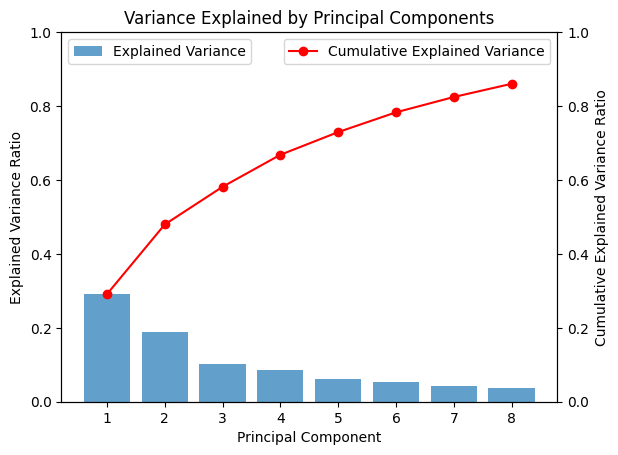

In [134]:
# Calculate cumulative variance explained
cumulative_variance = np.cumsum(variance_ratios)

# Create the plot
fig, ax1 = plt.subplots()

# Bar plot for explained variance
ax1.bar(range(1, len(variance_ratios) + 1), variance_ratios, alpha=0.7, label='Explained Variance')

# Line plot for cumulative variance explained
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, color='red', marker='o', label='Cumulative Explained Variance')

# Set y-axis limits
ax1.set_ylim(0, 1)
ax2.set_ylim(0, 1)

# Labels and title
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax2.set_ylabel('Cumulative Explained Variance Ratio')
plt.title('Variance Explained by Principal Components')

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

pd.DataFrame(variance_ratios).to_csv('results/PCA_Variance.csv')

# Show the plot
plt.savefig(results_dir + 'PCA_Variance.png')
plt.show()

In [62]:
ndf = pd.DataFrame(flattened_pca[:,0:3], columns=['PC1', 'PC2', 'PC3'])
ndf['file'] = unique_files

ndf['Background'] = 'WT'
ndf.loc[ndf['file'].str.contains('Tcof1'), 'Background'] = 'Tcof1'
ndf.loc[ndf['file'].str.contains('Splotch'), 'Background'] = 'Splotch'
ndf.loc[ndf['file'].str.contains('Splotch;Tcof1'), 'Background'] = 'Splotch;Tcof1'

from sklearn.manifold import TSNE
model = TSNE(n_components=2, random_state=0)
tsne_data = model.fit_transform(flattened_aligned)

ndf['TSNE1'] = tsne_data[:,0]
ndf['TSNE2'] = tsne_data[:,1]

In [63]:
reducer = umap.UMAP(random_state=42)
umap_data = reducer.fit_transform(flattened_aligned)

c:\Users\smc\AppData\Local\miniforge3\envs\napari2\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [64]:
ndf['UMAP1'] = umap_data[:,0]
ndf['UMAP2'] = umap_data[:,1]
ndf = pd.merge(ndf, means[['name', 'R']], left_on='file', right_on='name')

In [65]:
ndf

,PC1,PC2,PC3,file,Background,UMAP1,UMAP2,name,R
0,0.014958,-0.021057,0.012190,818236-3_Splotch;Tcof1_doublemut.csv,Splotch;Tcof1,10.777984,-7.101836,818236-3_Splotch;Tcof1_doublemut.csv,0.012449
1,-0.006541,-0.004761,0.009204,818236-5_Splotch_singlemut.csv,Splotch,10.628970,-7.999701,818236-5_Splotch_singlemut.csv,0.009421
2,-0.018036,0.000381,0.019831,818236-7_WT_2.csv,WT,9.247018,-7.812275,818236-7_WT_2.csv,0.008905
3,0.053750,-0.025990,0.014194,818236-8_Splotch;Tcof1_doublemut.csv,Splotch;Tcof1,10.314232,-6.476551,818236-8_Splotch;Tcof1_doublemut.csv,0.019566
4,-0.011891,0.005470,-0.011465,818236_2_Splotch_singlemut.csv,Splotch,9.823511,-8.210459,818236_2_Splotch_singlemut.csv,0.011119
5,-0.005504,0.030371,-0.022949,818978-1_Splotch;Tcof1_doublemut.csv,Splotch;Tcof1,9.433184,-9.447215,818978-1_Splotch;Tcof1_doublemut.csv,0.013177
6,-0.025019,0.020172,0.000688,818978-2_Splotch_singlemut.csv,Splotch,10.403472,-9.144753,818978-2_Splotch_singlemut.csv,0.010501
7,-0.028718,0.020900,-0.006935,818978-3_WT.csv,WT,9.850864,-8.915079,818978-3_WT.csv,0.009103
8,-0.019003,-0.010754,0.004886,818978-4_Tcof1_singlemut.csv,Tcof1,10.020331,-7.581734,818978-4_Tcof1_singlemut.csv,0.010329
9,-0.004069,0.037814,-0.002448,818978-5_Splotch_singlemut.csv,Splotch,9.172150,-8.933497,818978-5_Splotch_singlemut.csv,0.012611


# Plot Dimension Reduction

In [66]:
var = 'Background'

In [67]:
import plotly.graph_objs as go
import plotly.express as px

ndf['Size'] = ndf['R']**1.8
f=go.FigureWidget(
    px.scatter(ndf, x='PC1', y='PC2', height=800, width=1200, hover_data=['file'], size='Size', title='PCA of Procrustes aligned',
               color=var, category_orders=category_orders,
           #color_discrete_map={'WT':'rgb(0,0,255)', 'Mut_Interesting':'rgb(255, 0, 0)', 'Mut_NotInteresting':'rgb(0,255,0)'}
           )
    )

def click_fn(trace, points, state):
    
    if (len(points.point_inds)>0):
        idx = f.data[points.trace_index]['customdata'][points.point_inds[-1]][0]
        print(idx)
        viewer.layers.clear()
        img = ski.io.imread(idx.replace('.csv', '.tif'))
        viewer.add_image(img, channel_axis=-1, colormap=['red', 'green', 'blue'])

        tdf = pd.read_csv(idx)
        viewer.add_points(tdf.iloc[:,1:3].to_numpy(), size=40)

f.update_layout(
    plot_bgcolor='white',  # Set the plot background color to white
    paper_bgcolor='white',  # Set the paper background color to white
    xaxis=dict(
        showgrid=True,  # Show gridlines on the x-axis
        gridcolor='lightgray'  # Set the gridline color
    ),
    yaxis=dict(
        showgrid=True,  # Show gridlines on the y-axis
        gridcolor='lightgray'  # Set the gridline color
    )
)

for a in f.data:
    a.on_click(click_fn)

f.write_html(results_dir + 'PCA.html')
f.write_image(results_dir + 'PCA.png')
f

FigureWidget({
    'data': [{'customdata': array([['818236-7_WT_2.csv'],
                                   ['818978-3_WT.csv'],
                                   ['818978-7_WT.csv'],
                                   ['819576-8_WT.csv'],
                                   ['820352-6_WT.csv']], dtype=object),
              'hovertemplate': ('Background=WT<br>PC1=%{x}<br>P' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': 'WT',
              'marker': {'color': '#636efa',
                         'size': {'bdata': 'JNBVAdm4Kj/guPhZ9MwrP5O6ZPPq8SQ/1/nkLzesJj/AM6APfzYwPw==', 'dtype': 'f8'},
                         'sizemode': 'area',
                         'sizeref': np.float64(2.7185808165657396e-06),
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': 'WT',
              'orientation': 'v',
              'showlegend': True,
              'type': 'scatter',
              'uid': '15270df4-d829-4228-9c47-5b37f7911160'

In [72]:
from sklearn.cluster import KMeans
#kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans = KMeans(n_clusters=3)
ndf['Cluster'] = kmeans.fit_predict(flattened_pca[:,0:2]).astype(str)

f=go.FigureWidget(
    px.scatter(ndf, x='PC1', y='PC2', height=800, width=1200, hover_data=['file'], size='Size', title='PCA of Procrustes aligned', 
               symbol=var, color='Cluster',
           )
    )
f.write_html(results_dir + 'PCA_Clustered.html')
f

FigureWidget({
    'data': [{'customdata': array([['818236-3_Splotch;Tcof1_doublemut.csv']], dtype=object),
              'hovertemplate': ('Cluster=1<br>Background=Splotc' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': '1, Splotch;Tcof1',
              'marker': {'color': '#636efa',
                         'size': {'bdata': 'hg3K1lJrOD8=', 'dtype': 'f8'},
                         'sizemode': 'area',
                         'sizeref': np.float64(2.7185808165657396e-06),
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '1, Splotch;Tcof1',
              'orientation': 'v',
              'showlegend': True,
              'type': 'scatter',
              'uid': '9b4d0aa2-6e6b-43e0-b09a-9a54fe3689eb',
              'x': {'bdata': 'PgeHEXmijj8=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'ONPSVhSQlb8=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'customdata': array([['818

# ****************END USEFUL STUFF****************************************

In [215]:
import plotly.graph_objs as go
import plotly.express as px

ndf['Size'] = ndf['R']**1.8
f=go.FigureWidget(
    px.scatter(ndf, x='UMAP1', y='UMAP2', color=var, facet_col_wrap=3, hover_data=['file'], title='UMAP of Procrustes aligned', size='Size', height=800, width=800, category_orders=category_orders,)
    )

def click_fn(trace, points, state):
    
    if (len(points.point_inds)>0):
        idx = f.data[points.trace_index]['customdata'][points.point_inds[-1]][0]
        print(idx)
        viewer.layers.clear()
        img = ski.io.imread(idx.replace('.csv', '.tif'))
        viewer.add_image(img, channel_axis=-1, colormap=['red', 'green', 'blue'])

        tdf = pd.read_csv(idx)
        viewer.add_points(tdf.iloc[:,1:3].to_numpy())

for a in f.data:
    a.on_click(click_fn)
f.write_image('UMAP.png')
f.write_html('UMAP.html')
f

FigureWidget({
    'data': [{'customdata': array([['818236-7_WT.csv'],
                                   ['818978-3_WT.csv'],
                                   ['818978-7_WT.csv'],
                                   ['819576-8_WT.csv'],
                                   ['820352-6_WT.csv']], dtype=object),
              'hovertemplate': ('Background=WT<br>UMAP1=%{x}<br' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': 'WT',
              'marker': {'color': '#636efa',
                         'size': {'bdata': 'riwVLW+MMD++SURIeOc0P6xv+MR3rCQ/qk5fLVE5JT9xswZMbAEwPw==', 'dtype': 'f8'},
                         'sizemode': 'area',
                         'sizeref': np.float64(2.40259664096745e-06),
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': 'WT',
              'orientation': 'v',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'aa018df6-5e3f-4ed3-b58a-9454f63968fe',
  

# Looking at distances in dimension reduced space

In [37]:
var = 'GenoPheno'

In [38]:
distance_df = ndf.groupby([var]).agg({'PC1':'mean', 'PC2':'mean'}).reset_index()
distance_df['PC1'] = distance_df['PC1'] - distance_df[distance_df[var]=='WT_'].iloc[0]['PC1']
distance_df['PC2'] = distance_df['PC2'] - distance_df[distance_df[var]=='WT_'].iloc[0]['PC2']
distance_df['distance'] = np.sqrt(distance_df['PC1']**2 + distance_df['PC2']**2)
distance_df

,GenoPheno,PC1,PC2,distance
0,Mut_Mild,0.021422,-0.003944,0.021782
1,Mut_Severe,0.049832,0.016844,0.052602
2,WT_,0.000000,0.000000,0.000000


In [39]:
distance_df = ndf.groupby([var]).agg({'UMAP1':'mean', 'UMAP2':'mean'}).reset_index()
centroid1 = ndf[ndf[var]=='WT_']['UMAP1'].mean()
centroid2 = ndf[ndf[var]=='WT_']['UMAP2'].mean()

ndf['UMAP1'] = ndf['UMAP1'] - centroid1
ndf['UMAP2'] = ndf['UMAP2'] - centroid2
ndf['distance'] = np.sqrt(ndf['UMAP1']**2 + ndf['UMAP2']**2)
px.box(ndf, x=var, y='distance', title='UMAP distance from WT centroid', points='all', width=600, category_orders=category_orders)

In [40]:
px.violin(ndf, x=var, y='distance', title='UMAP distance from WT centroid', points='all', width=600, category_orders=category_orders)

# Looking at statistical significance

This is actually pretty cool.  You give it multidimensional data and the classes (can have more than one class but I strip it down to just two to make it simple), then give it an ML function you might use for classification like LogisticRegression or SVC(kernel='linear').  It looks at the accuracy of the classifier, then compares that accuracy to when it re-trains the classifier on randomly assigned data over and over again.  If the classes mean anything then the accuracy should be statistically significant for the real assignments vs the random ones.

In [41]:
from sklearn.model_selection import permutation_test_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import numpy as np

In [42]:
ndf['GenoPheno'].value_counts()

GenoPheno
Mut_Severe    47
Mut_Mild      39
WT_           11
Name: count, dtype: int64

In [43]:
def multidimensional_statistical_test(X, y):
    svm = SVC(kernel='linear')

    # Perform the permutation test.
    score, permutation_scores, pvalue = permutation_test_score(
        LogisticRegression(), X, y, scoring="accuracy", cv=None, n_permutations=100, n_jobs=1)
    return score, pvalue


In [45]:
var = 'GenoPheno'
codes = ['WT_', 'Mut_Mild', 'Mut_Moderate', 'Mut_Severe']
codes = ['WT_', 'Mut_Mild', 'Mut_Severe']
#codes = ndf[var].unique()
#codes = codes[codes!='WT_']
#codes = ['Mut']
pvals = [1.0]
for code in codes:
    if code == 'WT_':
        continue
    tdf = ndf[(ndf[var]==code) | (ndf[var]=='WT_')]
    X = tdf.loc[:,['UMAP1', 'UMAP2']].to_numpy()
    y = tdf[var]
    score, pvalue = multidimensional_statistical_test(X, y)
    print(f'{code} vs WT: {score} (pvalue: {pvalue}')
    pvals.append(pvalue)


Mut_Mild vs WT: 0.8 (pvalue: 0.019801980198019802
Mut_Severe vs WT: 0.8075757575757576 (pvalue: 0.7227722772277227


In [46]:
title='UMAP distance from WT centroid<br>Test p-values: ' + ', '.join(["{:.1e}".format(pvals[i]) for i in range(len(codes))])

In [47]:
f = px.box(ndf, x=var, y='distance', points='all', category_orders={var:['WT_', 'Mut_Mild', 'Mut_Moderate', 'Mut_Severe']}, width=800,
       title=title)
f.write_html('UMAP_distance.html')
f